In [239]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import animation, rc

In [104]:
def color_variant(hex_color, brightness_offset=1):
    """ takes a color like #87c95f and produces a lighter or darker variant """
    if len(hex_color) != 7:
        raise Exception("Passed %s into color_variant(), needs to be in #87c95f format." % hex_color)
    rgb_hex = [hex_color[x:x+2] for x in [1, 3, 5]]
    new_rgb_int = [int(hex_value, 16) + brightness_offset for hex_value in rgb_hex]
    new_rgb_int = [min([255, max([0, i])]) for i in new_rgb_int] # make sure new values are between 0 and 255
    # hex() produces "0x88", we want just "88"
    add = ''
    if hex_color[1] == '0':
        add = '0'
    return "#" + add + "".join([hex(i)[2:] for i in new_rgb_int])

<IPython.core.display.Javascript object>


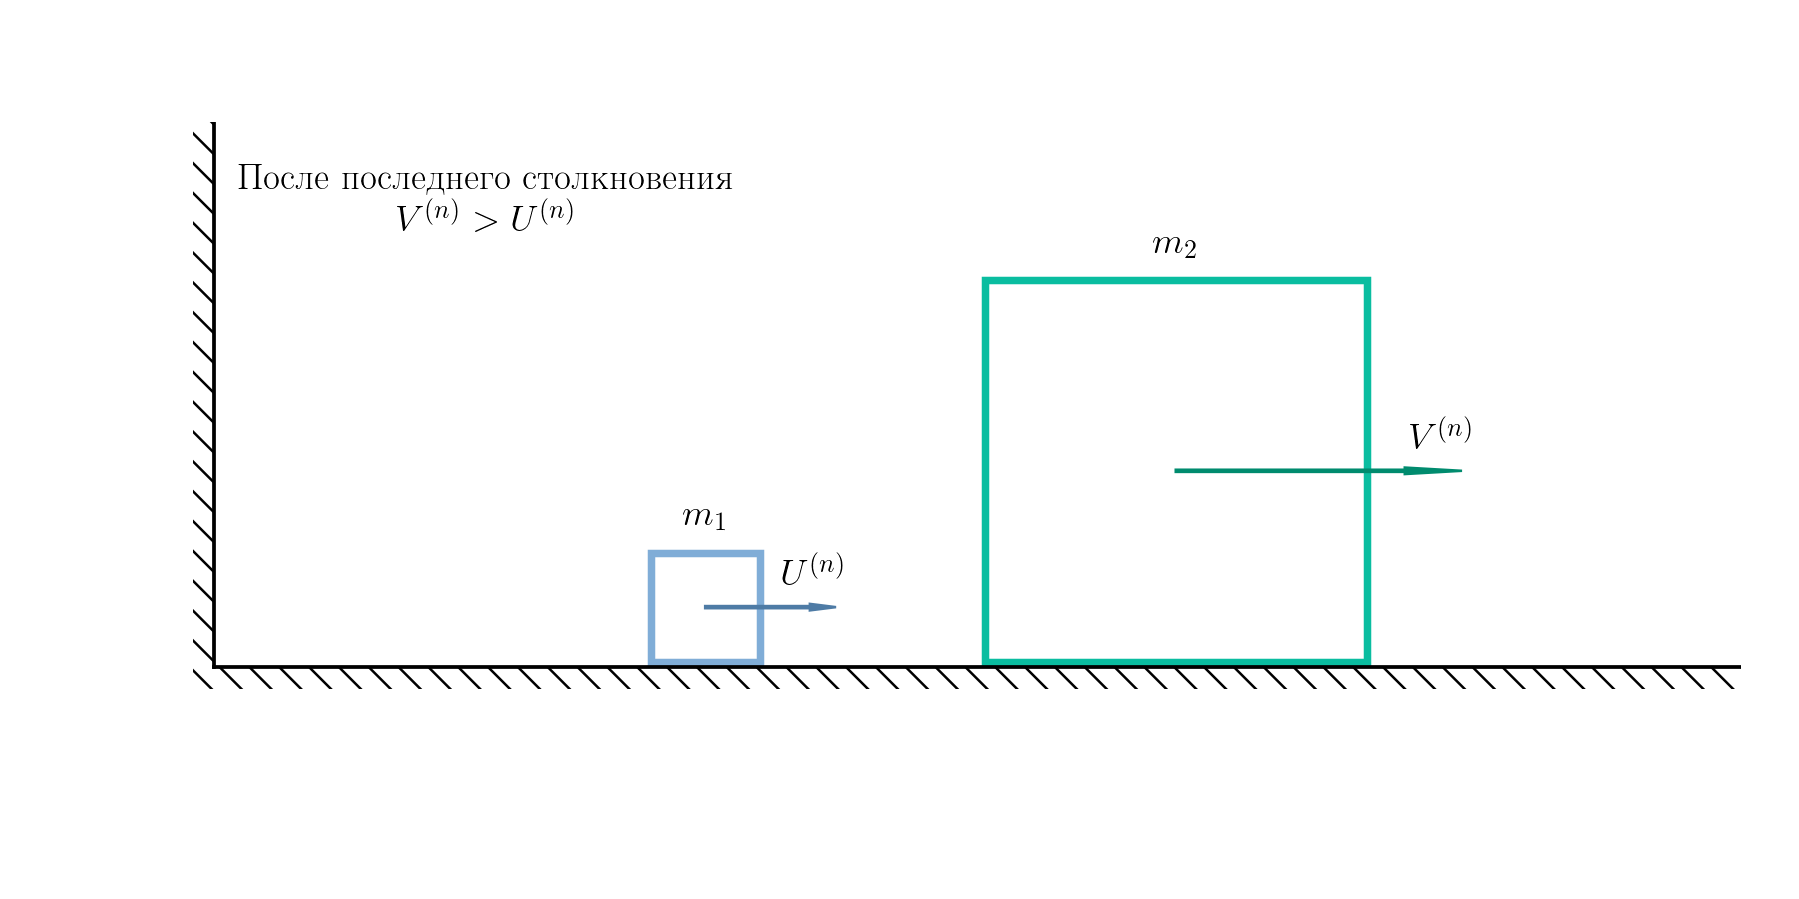

In [187]:
%matplotlib notebook
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 15})
rc('text', usetex=True)
rc('text.latex',unicode=True)
rc('text.latex',preamble=r'\usepackage[utf8]{inputenc}')
rc('text.latex',preamble=r'\usepackage[russian]{babel}')
mpl.rcParams['text.latex.unicode'] = True

plt.figure(figsize=(10, 5))
ax = plt.subplot(111)
ax.set_xlim(-1, 14)
ax.set_ylim(-1, 5)
ax.set_aspect(1)
ax.axvline(0, ymin=1/6, c='black')
ax.fill([0, 14, 14, 0], [-.2, -.2, 0, 0], fill=False, hatch='\\\\', linewidth=0)
ax.axhline(0, xmin=1/15, c='black')
ax.fill([-.2, 0, 0, -.2], [-.2, -.2, 5, 5], fill=False, hatch='\\\\', linewidth=0)
ax.axis('off')

tiny_gap = 0.05

x1, y1 = (5, tiny_gap)
h1, w1 = (1, 1)
x2, y2 = (10, tiny_gap)
h2, w2 = (3.5, 3.5)

c1 = '#80add7'
c1d = color_variant(c1, brightness_offset=-50)
c2 = '#0abda0'
c2d = color_variant(c2, brightness_offset=-50)

r1 = mpl.patches.Rectangle((x1, y1), h1, w1, fill=False, edgecolor=c1, lw=3)
r2 = mpl.patches.Rectangle((x2, y2), h2, w2, fill=False, edgecolor=c2, lw=3)
ax.add_artist(r1)
ax.add_artist(r2)

r2.set_x(x1 + w1 + x1 / 5 + tiny_gap * 1.3)
r1.set_x(x1 - w1)

arr1 = mpl.patches.Arrow(r1.get_x() + w1 / 2, y1 + h1/2, w1 * 1.2, 0, width=0.1, color=c1d)
arr2 = mpl.patches.Arrow(r2.get_x() + w2 / 2, y2 + h2/2, w2 * 3/4, 0, width=0.1, color=c2d)

ax.add_artist(arr1)
ax.add_artist(arr2)

ax.text(r1.get_x() + w1 / 2, y1 + h1 + h1 / 5, r"$m_1$", ha='center')
ax.text(r2.get_x() + w2 / 2, y2 + h2 + h1 / 5, r"$m_2$", ha='center')
ax.text(r1.get_x() + w1 + w1 / 2, y1 + h1 / 2 + h1 / 5, r"$U^{(n)}$", ha='center')
ax.text(r2.get_x() + w2 + w2 / 5, y2 + h2 / 2 + h1 / 5, r"$V^{(n)}$", ha='center')

ax.text(2.5, 4, "После последнего столкновения" + "\n" + r"$V^{(n)} > U^{(n)}$", ha='center')

plt.tight_layout();
plt.savefig('pic4.png', dpi=240)

In [280]:
tiny_gap = 0.05
        
class Block:
    def __init__(self, ax, x, s, v, c, mass_):
        self.x = x
        self.s = s
        self.v = v
        self.c = c
        self.arr_color = color_variant(c, brightness_offset=-50)
        self.arr = mpl.patches.Arrow(x + s / 2, s / 2, v, 0, width=0.1, color=self.arr_color)
        self.obj = mpl.patches.Rectangle((x, tiny_gap), s, s, fill=False, edgecolor=c, lw=3)
        self.m_txt = mpl.text.Annotation(mass_, (x + s / 2, s + s / 5), ha='center')
        self.ax = ax
        self.ax.add_artist(self.obj)
        self.ax.add_artist(self.arr)
        self.ax.add_artist(self.m_txt)
    def move(self):
        self.x += self.v * 0.001
        self.arr.remove()
        self.arr = mpl.patches.Arrow(self.x + self.s / 2, self.s / 2, self.v, 0, width=0.1, color=self.arr_color)
        self.ax.add_artist(self.arr)
        self.obj.set_x(self.x)
        self.m_txt.set_x(self.x + self.s / 2)
        
class Collisor:
    def __init__(self, cntr, ac):
        self.cntr = cntr
        self.ac = ac
        
class ncolText:
    def __init__(self, ax, num):
        self.num = num
        self.obj = mpl.text.Annotation(self.num, (2, 4), ha='center', fontsize=20)
        self.ax = ax
        self.ax.add_artist(self.obj)
    def increase(self, by = 1):
        self.num += by
        self.obj.set_text(self.num)

<IPython.core.display.Javascript object>


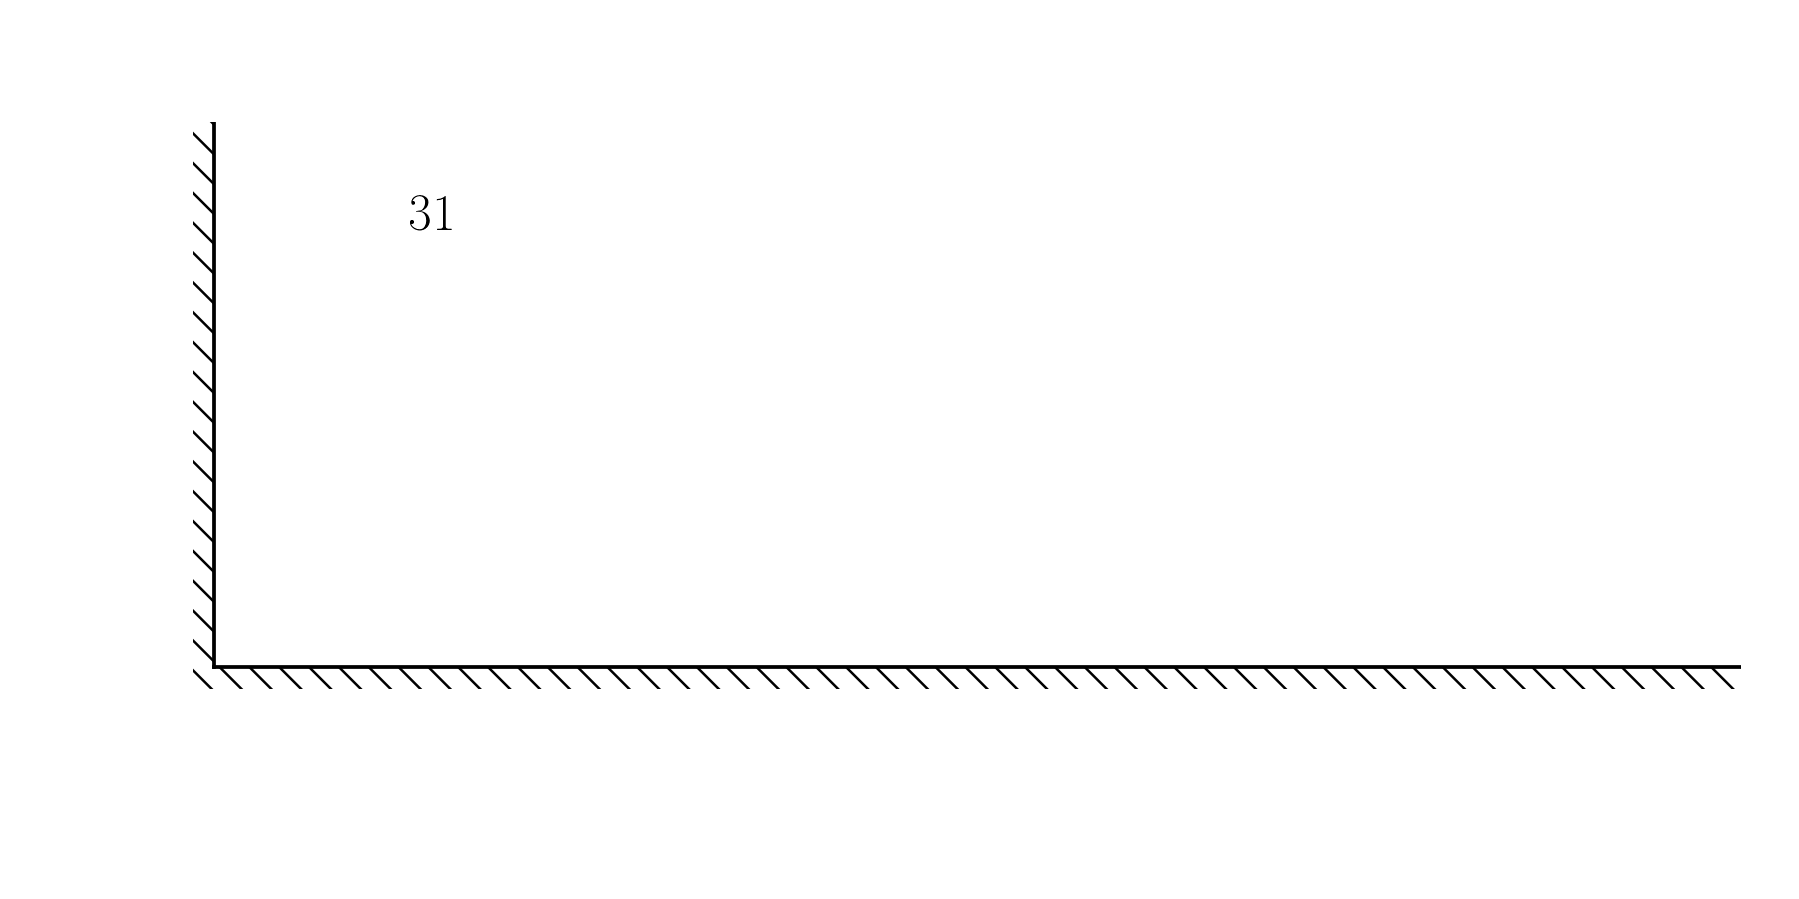

In [291]:
%matplotlib notebook
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 15})
rc('text', usetex=True)
rc('text.latex',unicode=True)
rc('text.latex',preamble=r'\usepackage[utf8]{inputenc}')
rc('text.latex',preamble=r'\usepackage[russian]{babel}')
mpl.rcParams['text.latex.unicode'] = True

fig, ax = plt.subplots(figsize=(10,5))
ax.set_xlim(-1, 14)
ax.set_ylim(-1, 5)
ax.set_aspect(1)
ax.axvline(0, ymin=1/6, c='black')
ax.fill([0, 14, 14, 0], [-.2, -.2, 0, 0], fill=False, hatch='\\\\', linewidth=0)
ax.axhline(0, xmin=1/15, c='black')
ax.fill([-.2, 0, 0, -.2], [-.2, -.2, 5, 5], fill=False, hatch='\\\\', linewidth=0)
ax.axis('off')

m1 = 1
m2 = 100
block1 = Block(ax, 5, 1, 0, '#80add7', r'$m$')
block2 = Block(ax, 10, 1, -1.5, '#0abda0', r'$2m$')

coll = ncolText(ax, 0)

collisor = Collisor(1000, False)
def animate(i):
    collisor.cntr += 1
    block1.move()
    block2.move()
    if ((block2.x - block1.x <= block1.s) and (collisor.cntr > 10)): # blocks collision
        collisor.cntr = 0
        v1 = block1.v
        v2 = block2.v
        block1.v = (m1 * v1 - m2 * v1 + 2 * m2 * v2) / (m1 + m2)
        block2.v = (2 * m1 * v1 - m1 * v2 + m2 * v2) / (m1 + m2)
        coll.increase()
    if ((block1.x <= 0) and (collisor.cntr > 10)): # block/wall collision
        collisor.cntr = 0
        block1.v = -block1.v
        coll.increase()
    plt.tight_layout()
    
anim = animation.FuncAnimation(fig, animate, np.arange(0, 3500), interval=1, repeat=False)
anim.save('anim2.gif', writer='imagemagick', fps=60)